# IMPORTS

In [1]:
import os
import time
import json
import torch
import logging
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple
from datetime import timedelta
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

import wandb

# Setup Logging & Reproducibility
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

In [3]:
print(f"Kiến trúc GPU hiện tại: {torch.cuda.get_device_capability()}")
print(f"Danh sách kiến trúc PyTorch hỗ trợ: {torch.cuda.get_arch_list()}")

Kiến trúc GPU hiện tại: (7, 5)
Danh sách kiến trúc PyTorch hỗ trợ: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [4]:
wandb.login(key=wandb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lethanhthangdat (lethanhthangdat109) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# CONFIGURATIONS

In [5]:
# =============================================================================
# 1. CONFIGURATION
# =============================================================================
CONFIG = {
    "model_name":        "google-bert/bert-base-uncased",
    "train_path":        "/kaggle/input/datasets/lthnhthngt/cs221-v2/train_clean.csv",
    "val_path":          "/kaggle/input/datasets/lthnhthngt/cs221-v2/val_clean.csv",
    "test_path":         "/kaggle/input/datasets/lthnhthngt/cs221-v2/test_clean.csv",
    
    "text_col":          "text",
    "label_col":         "label",
    "class_names":       ["Normal", "Depression", "Suicidal", "Anxiety"], 
    
    "max_seq_length":    300,
    "batch_size":        64,
    "epochs":            5,
    "learning_rate":     2e-5,
    "adam_epsilon":      1e-10,
    "adam_beta1":        0.9,
    "adam_beta2":        0.95,
    "weight_decay":      0.01,
    "warmup_ratio":      0.1,
    "label_smoothing_factor": 0.2,
    "lr_scheduler_type": "cosine", 
    "accumulation_steps": 1,

    "hidden_dropout": 0.1,
    "attn_dropout": 0.1,
    "classifier_dropout": 0.1,
    
    "output_dir":        "/kaggle/working/checkpoints",
    "log_dir":           "/kaggle/working/logs",
    "fp16":              True,     
    "seed":              42,
    "early_stopping_patience": 2,
}

In [6]:
CONFIG["num_labels"] = len(CONFIG["class_names"])
CONFIG["id2label"] = {i: label for i, label in enumerate(CONFIG["class_names"])}
CONFIG["label2id"] = {label: i for i, label in enumerate(CONFIG["class_names"])}

In [7]:
set_seed(CONFIG["seed"])

# DATASET

In [8]:
# =============================================================================
# 2. DATASET PREPARATION
# =============================================================================
class MentalHealthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        tokenizer.truncation_side = 'right' 
        self.encodings = tokenizer(
            texts, 
            truncation=True, 
            padding="max_length", 
            max_length=max_len,
            return_token_type_ids=True,
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

def load_and_preprocess_data(path, cfg):
    df = pd.read_csv(path).dropna(subset=[cfg["text_col"], cfg["label_col"]])
    texts = df[cfg["text_col"]].astype(str).tolist()
    labels = df[cfg["label_col"]].map(cfg["label2id"]).astype(int).tolist()
    return texts, labels

# METRICS

In [9]:
# =============================================================================
# 3. METRICS CALLBACK
# =============================================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

# TRAINER

In [10]:
class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is not None:
            self.class_weights = class_weights.to(self.model.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

# TRAINING

In [11]:
tokenizer = BertTokenizerFast.from_pretrained(CONFIG["model_name"])
special_tokens = ["<username>", "<url>", "<name>", "<number>", "<emoji>"]
tokenizer.add_special_tokens({"additional_special_tokens": special_tokens})

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/vocab.txt "HTTP/1.1 200 OK"


vocab.txt: 0.00B [00:00, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/tokenizer.json "HTTP/1.1 200 OK"


tokenizer.json: 0.00B [00:00, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/special_tokens_map.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"


5

In [12]:
# Load data
train_texts, train_labels = load_and_preprocess_data(CONFIG["train_path"], CONFIG)
val_texts, val_labels = load_and_preprocess_data(CONFIG["val_path"], CONFIG)
test_texts, test_labels = load_and_preprocess_data(CONFIG["test_path"], CONFIG)

# Tạo dataset 
train_dataset = MentalHealthDataset(train_texts, train_labels, tokenizer, CONFIG["max_seq_length"])
val_dataset   = MentalHealthDataset(val_texts, val_labels, tokenizer, CONFIG["max_seq_length"])
test_dataset  = MentalHealthDataset(test_texts, test_labels, tokenizer, CONFIG["max_seq_length"])

In [13]:
# --- Initialize Model ---
model = BertForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=len(CONFIG["id2label"]),
    id2label=CONFIG["id2label"],
    label2id=CONFIG["label2id"],
    hidden_dropout_prob=CONFIG["hidden_dropout"],           
    attention_probs_dropout_prob=CONFIG["attn_dropout"],
    classifier_dropout=CONFIG["classifier_dropout"]
)

model.resize_token_embeddings(len(tokenizer))

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-uncased/86b5e0934494bd15c9632b12f734a8a67f723594/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google-bert/bert-base-uncased/xet-read-token/86b5e0934494bd15c9632b12f734a8a67f723594 "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will b

Embedding(30527, 768, padding_idx=0)

In [14]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels 
)

weights_tensor = torch.tensor(class_weights, dtype=torch.float)

In [15]:
# --- Training Arguments ---
training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"] * 2,
    
    learning_rate=CONFIG["learning_rate"],
    adam_epsilon=CONFIG["adam_epsilon"],
    adam_beta1=CONFIG["adam_beta1"],
    adam_beta2=CONFIG["adam_beta2"],
    weight_decay=CONFIG["weight_decay"],
    label_smoothing_factor=CONFIG["label_smoothing_factor"],
    lr_scheduler_type=CONFIG["lr_scheduler_type"],
    warmup_ratio=CONFIG["warmup_ratio"],
    gradient_accumulation_steps=CONFIG["accumulation_steps"],
    
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    
    logging_dir=CONFIG["log_dir"],
    logging_strategy="steps",
    logging_first_step=True,
    logging_steps=40,
    log_level="info",   

    fp16=CONFIG["fp16"],
    report_to="wandb",
    run_name="CS221_V10.11 (Removed)",
    
    dataloader_num_workers=os.cpu_count(),
    dataloader_pin_memory=True,
    disable_tqdm=False
)

# --- Trainer ---
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    class_weights=weights_tensor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["early_stopping_patience"])]
)

# --- TRAINING ---
print(f"\n🚀 Starting training with {CONFIG['lr_scheduler_type']} scheduler...")
start_train_time = time.time()
trainer.train()
total_train_time = time.time() - start_train_time
print(f"\n✅ Training complete! Total time: {timedelta(seconds=int(total_train_time))}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
***** Running training *****
  Num examples = 33,682
  Num Epochs = 5
  Instantaneous batch size per device = 64
  Training with DataParallel so batch size has been adjusted to: 128
  Total train batch size (w. parallel, distributed & accumulation) = 128
  Gradient Accumulation steps = 1
  Total optimization steps = 1,320
  Number of trainable parameters = 109,489,156



🚀 Starting training with cosine scheduler...


wandb: setting up run fp976xjl
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260516_182252-fp976xjl
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run CS221_V10.11 (Removed)
wandb: ⭐️ View project at https://wandb.ai/lethanhthangdat109/huggingface
wandb: 🚀 View run at https://wandb.ai/lethanhthangdat109/huggingface/runs/fp976xjl


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.534854,0.464277,0.799353,0.782882
2,0.393886,0.408830,0.827805,0.820478
3,0.324604,0.403137,0.844795,0.837038
4,0.264901,0.405542,0.846009,0.838194
5,0.223806,0.415926,0.846548,0.839557



***** Running Evaluation *****
  Num examples = 7416
  Batch size = 256
Saving model checkpoint to /kaggle/working/checkpoints/checkpoint-264
Configuration saved in /kaggle/working/checkpoints/checkpoint-264/config.json


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/checkpoints/checkpoint-1056/model.safetensors

***** Running Evaluation *****
  Num examples = 7416
  Batch size = 256
Saving model checkpoint to /kaggle/working/checkpoints/checkpoint-1320
Configuration saved in /kaggle/working/checkpoints/checkpoint-1320/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/checkpoints/checkpoint-1320/model.safetensors


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from /kaggle/working/checkpoints/checkpoint-1320 (score: 0.8395565419650355).
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.outpu


✅ Training complete! Total time: 1:27:30


In [16]:
final_model_path = os.path.join(CONFIG["output_dir"], "final_model")

trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"✅ Model và Tokenizer đã được lưu tại: {final_model_path}")

Saving model checkpoint to /kaggle/working/checkpoints/final_model
Configuration saved in /kaggle/working/checkpoints/final_model/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /kaggle/working/checkpoints/final_model/model.safetensors
tokenizer config file saved in /kaggle/working/checkpoints/final_model/tokenizer_config.json


✅ Model và Tokenizer đã được lưu tại: /kaggle/working/checkpoints/final_model


In [17]:
# --- INFERENCE & EVALUATION ON TEST SET ---
print("\n🔍 Running inference on test set...")
start_inf_time = time.time()
predictions = trainer.predict(test_dataset)
total_inf_time = time.time() - start_inf_time

avg_inf_latency = (total_inf_time / len(test_dataset)) * 1000 # ms per sample

y_preds = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids


***** Running Prediction *****
  Num examples = 7415
  Batch size = 256



🔍 Running inference on test set...


In [18]:
# =============================================================================
# 5. FINAL RESULTS & VISUALIZATION
# =============================================================================
print("\n" + "="*20 + " FINAL TEST RESULTS " + "="*20)
print(f"Total Training Time  : {timedelta(seconds=int(total_train_time))}")
print(f"Avg Inference Latency: {avg_inf_latency:.2f} ms/sample")
print("-" * 60)

# Classification Report
report = classification_report(
    y_true, y_preds, target_names=list(CONFIG["id2label"].values()), digits=4
)
print(report)


==================== FINAL TEST RESULTS ====================
Total Training Time  : 1:27:30
Avg Inference Latency: 9.89 ms/sample
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal     0.9640    0.9427    0.9532      2723
  Depression     0.8209    0.7413    0.7790      2176
    Suicidal     0.7338    0.8268    0.7775      1680
     Anxiety     0.8512    0.9103    0.8798       836

    accuracy                         0.8537      7415
   macro avg     0.8425    0.8553    0.8474      7415
weighted avg     0.8571    0.8537    0.8540      7415



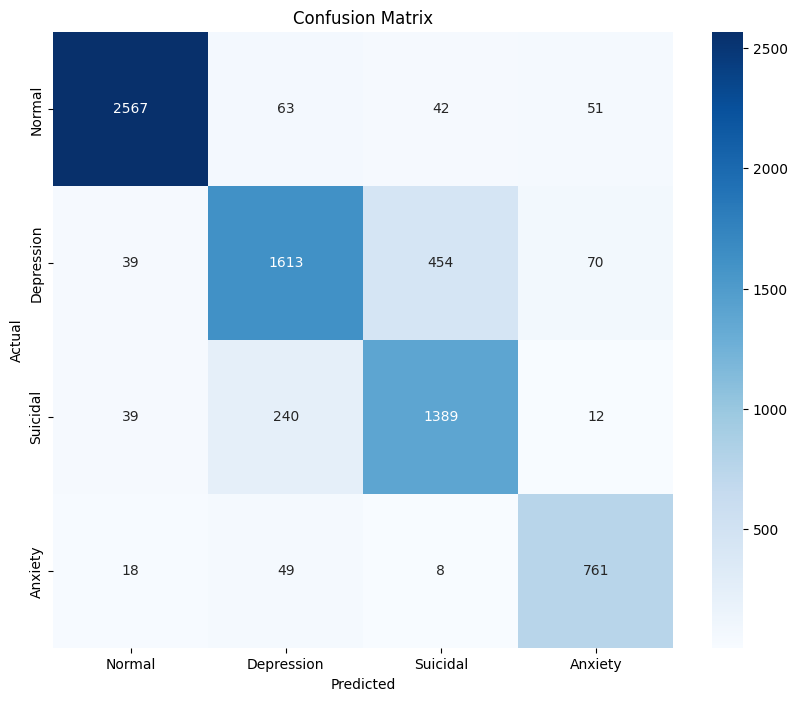

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CONFIG["id2label"].values(),
    yticklabels=CONFIG["id2label"].values()
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig(f"{CONFIG['output_dir']}/confusion_matrix.png")
plt.show()

# Lưu kết quả ra file
with open(f"{CONFIG['output_dir']}/test_summary.json", "w") as f:
    json.dump({
        "train_time_sec": total_train_time,
        "avg_inference_latency_ms": avg_inf_latency,
        "test_accuracy": accuracy_score(y_true, y_preds),
        "test_f1_macro": f1_score(y_true, y_preds, average="macro")
    }, f, indent=4)